# Evaluación de estrategias de adaptación de dominio para la detección de tizón tardío en cultivos de papa bajo condiciones andinas

**Curso:** Inteligencia Artificial Aplicada (1INF62) — PUCP  
**Grupo 1:** Vasquez, P. · Carranza, I. · Regalado, R. · Torres, R. · Carbajal, F.

---

## 1. Introducción y objetivo

La **rancha o tizón tardío** (*Phytophthora infestans*) es una de las principales amenazas del
cultivo de papa en la sierra peruana. Los modelos de visión computacional entrenados con
imágenes de un dominio fuente pueden presentar una caída de desempeño cuando se evalúan sobre
**imágenes reales de campo**. Este notebook implementa un experimento de adaptación de dominio
para medir y reducir esa brecha.

**Objetivo experimental:** comparar la generalización de un clasificador de hojas de papa
entrenado en el dataset **Potato Disease Leaf Dataset (PLD)** de Kaggle como dominio fuente,
y evaluarlo sobre el **Dataset Tanzano** como dominio objetivo de campo real.

**Clases (3):** `healthy`, `early_blight`, `late_blight`.

**Modelo base:** *transfer learning* con **EfficientNetB0** preentrenada en ImageNet.

| Sigla | Estrategia | Datos de entrenamiento | Idea principal |
|-------|------------|------------------------|----------------|
| **MB**  | Modelo Base | PLD, sin aumento intensivo | Línea base, mide la brecha original |
| **MA**  | Modelo con Aumento de datos | PLD + *data augmentation* de campo + fine-tuning parcial | Reducir la brecha desde el dominio fuente |
| **MFT** | Fine-tuning *K-shot* | Parte de MA + 20 muestras por clase de Tanzano | Adaptar al dominio objetivo con datos mínimos |

> La evaluación más importante es sobre `target_test_ds` — Tanzano reservado, no usado para entrenamiento.

### Ajustes de esta versión

- Reemplaza PLD por **PLD** como dominio fuente.
- Prepara descarga directa del dominio fuente desde Kaggle usando `kagglehub`.
- Mantiene **Tanzano** como dominio objetivo.
- Mantiene **EfficientNetB0** como backbone.
- Mantiene entrenamiento con **EarlyStopping**.
- Mantiene fine-tuning parcial del último porcentaje de capas, congelando BatchNormalization.
- Corrige el **K-shot** para que sea balanceado: `K_SHOT = 20` imágenes por clase.
- Elimina credenciales hardcodeadas de Kaggle.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Importación de librerías

In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# --- Librerias estandar ---
import os
import sys
import random
import shutil
import zipfile
import subprocess
import warnings
from pathlib import Path

# --- Manejo de datos y graficos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# --- TensorFlow / Keras ---
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPUs detectadas:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- scikit-learn (particion estratificada y metricas) ---
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

warnings.filterwarnings("ignore")

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configuración inicial

Constantes del experimento, semilla de reproducibilidad y rutas base para ejecución en **Google Colab** o entorno local.


In [ ]:
# --------------------------- Hiperparametros ---------------------------
IMG_SIZE     = (224, 224)
IMG_SHAPE    = IMG_SIZE + (3,)
BATCH_SIZE   = 16
SEED         = 42
NUM_CLASSES  = 3

# --- Epocas MAXIMAS por fase (con EarlyStopping se detiene antes si no mejora) ---
MAX_EPOCHS_MB      = 100;  PATIENCE_MB      = 10
MAX_EPOCHS_MA_HEAD = 100;  PATIENCE_MA_HEAD = 10
MAX_EPOCHS_MA_FT   = 50;   PATIENCE_MA_FT   = 5
MAX_EPOCHS_MFT     = 50;   PATIENCE_MFT     = 5
EPOCHS_SANITY      = 30    # sanity check sobre subconjunto pequeno

# K-shot: imagenes por clase de Tanzano para adaptar
K_SHOT = 20

# Muestreo del dominio objetivo.
# None = usar todo el dataset objetivo, lo cual puede ser lento.
# Recomendado para Colab: 600 a 1000 por clase.
TARGET_SAMPLE_PER_CLASS = 600

# --- Manejo del desbalance ---
# Con PLD el desbalance suele ser menor que en PlantVillage, pero se conserva la opcion.
USE_CLASS_WEIGHT = False
CLASS_WEIGHT_MAX = 2.0

# Tasas de aprendizaje
LR_HEAD = 1e-3
LR_FT   = 1e-5
LR_MFT  = 1e-5

AUTOTUNE = tf.data.AUTOTUNE

# --------------------------- Descarga / rutas Colab ---------------------------
# Dominio fuente: PLD desde Kaggle
SOURCE_KAGGLE_DATASET = "rizwan123456789/potato-disease-leaf-datasetpld"

# Dominio objetivo: Tanzano.
# En este notebook se usa por defecto un ZIP guardado en Google Drive.
TARGET_MODE = "drive_zip"      # opciones: "drive_zip", "local", "zenodo", "kaggle"

# Ruta del ZIP que subiste a Google Drive:
# Mi unidad/IA_APLICADA/Dataset_Tanzano.zip
TARGET_DRIVE_ZIP = Path("/content/drive/MyDrive/IA_APLICADA/Dataset_Tanzano.zip")

# Carpeta donde se descomprimira Tanzano dentro del disco temporal de Colab.
# Es mejor entrenar desde /content que leer miles de imagenes directamente desde Drive.
TARGET_EXTRACT_DIR = Path("/content/Dataset_Tanzano")

# Opciones alternativas por si se quiere cambiar el modo
TARGET_KAGGLE_DATASET = ""     # ejemplo: "usuario/dataset-tanzano" si lo subieron a Kaggle
TARGET_LOCAL_DIR = Path("/content/Dataset_Tanzano")

# Carpeta de trabajo en Colab/local
BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
DATA_DIR = BASE_DIR / "data_papa"

# Guardado de resultados.
# Se recomienda guardar modelos, tablas y figuras en Drive para no perderlos si Colab se reinicia.
SAVE_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUTS_DIR = Path("/content/drive/MyDrive/IA_APLICADA/outputs_adaptacion_papa")

# Carpeta temporal inicial. Luego, si Drive se monta correctamente, se reasigna a DRIVE_OUTPUTS_DIR.
OUTPUTS_DIR = BASE_DIR / "outputs"
MODELS_DIR  = OUTPUTS_DIR / "models"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR  = OUTPUTS_DIR / "tables"
LOGS_DIR    = OUTPUTS_DIR / "logs"

for d in [DATA_DIR, OUTPUTS_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Estas rutas se completan luego de la descarga / deteccion.
SOURCE_DIR = None
TARGET_DIR = None

# Semilla para reproducibilidad
def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(SEED)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUTS_DIR inicial:", OUTPUTS_DIR)


BASE_DIR: /content
DATA_DIR: /content/data_papa
OUTPUTS_DIR inicial: /content/outputs


## 3.1 Descarga y localización de datasets

Esta sección prepara el notebook para **Google Colab** sin usar rutas locales de VS Code.

- El dominio fuente **PLD** se descarga directamente desde Kaggle con `kagglehub`.
- El dominio objetivo **Tanzano** se toma desde un archivo ZIP guardado en Google Drive:
  `Mi unidad/IA_APLICADA/Dataset_Tanzano.zip`.
- El ZIP se copia a `/content` y se descomprime ahí para que el entrenamiento no lea miles de imágenes pequeñas directamente desde Drive.
- Los resultados se guardan en Drive para no perder modelos, tablas ni figuras si Colab se reinicia.

No se debe escribir el token de Kaggle dentro del notebook.

In [ ]:
# Instalacion segura de kagglehub si no existe
try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub


def estamos_en_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


def montar_drive_si_corresponde():
    """Monta Google Drive solo cuando estamos en Colab y se necesita Drive."""
    necesita_drive = (TARGET_MODE == "drive_zip") or SAVE_OUTPUTS_TO_DRIVE
    if estamos_en_colab() and necesita_drive:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive montado en /content/drive")
    elif necesita_drive:
        print("No parece ser Colab. Se asumira que las rutas de Drive ya estan disponibles localmente.")


def configurar_salida_en_drive():
    """Reasigna las carpetas de salida a Google Drive para conservar resultados."""
    global OUTPUTS_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR

    if SAVE_OUTPUTS_TO_DRIVE:
        OUTPUTS_DIR = Path(DRIVE_OUTPUTS_DIR)
    else:
        OUTPUTS_DIR = BASE_DIR / "outputs"

    MODELS_DIR  = OUTPUTS_DIR / "models"
    FIGURES_DIR = OUTPUTS_DIR / "figures"
    TABLES_DIR  = OUTPUTS_DIR / "tables"
    LOGS_DIR    = OUTPUTS_DIR / "logs"

    for d in [OUTPUTS_DIR, MODELS_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
        d.mkdir(parents=True, exist_ok=True)

    print("OUTPUTS_DIR final:", OUTPUTS_DIR)
    print("MODELS_DIR:", MODELS_DIR)


def descargar_desde_kaggle(slug, nombre):
    """Descarga un dataset publico de Kaggle usando kagglehub y devuelve la ruta local cacheada."""
    if not slug:
        raise ValueError(f"No se definio slug de Kaggle para {nombre}.")
    print(f"Descargando {nombre} desde Kaggle: {slug}")
    path = Path(kagglehub.dataset_download(slug))
    print(f"{nombre} disponible en:", path)
    return path


def extraer_zip_seguro(zip_path, extract_dir):
    """Extrae un ZIP evitando reextraer si la carpeta ya contiene archivos."""
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)

    if not zip_path.exists():
        raise FileNotFoundError(
            f"No se encontro el ZIP de Tanzano en:\n{zip_path}\n\n"
            "Verifica que en Drive exista: Mi unidad/IA_APLICADA/Dataset_Tanzano.zip"
        )

    if extract_dir.exists() and any(extract_dir.rglob("*")):
        print(f"Tanzano ya esta descomprimido en {extract_dir}. Se reutilizara.")
        return extract_dir

    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"Extrayendo {zip_path.name} en {extract_dir}. Puede tardar varios minutos...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    print("Extraccion finalizada.")
    return extract_dir


def preparar_tanzano_desde_drive_zip(drive_zip, extract_dir):
    """
    Copia el ZIP de Tanzano desde Drive a /content y luego lo descomprime en /content.
    Esto evita leer miles de imagenes directamente desde Google Drive.
    """
    drive_zip = Path(drive_zip)
    extract_dir = Path(extract_dir)

    if not drive_zip.exists():
        raise FileNotFoundError(
            f"No se encontro el ZIP en Drive:\n{drive_zip}\n\n"
            "Ruta esperada: /content/drive/MyDrive/IA_APLICADA/Dataset_Tanzano.zip"
        )

    local_zip = DATA_DIR / drive_zip.name

    if local_zip.exists() and local_zip.stat().st_size == drive_zip.stat().st_size:
        print(f"ZIP local ya existe y coincide en tamano: {local_zip}")
    else:
        print(f"Copiando ZIP desde Drive a disco temporal de Colab:")
        print(f"  origen : {drive_zip}")
        print(f"  destino: {local_zip}")
        shutil.copy2(drive_zip, local_zip)
        print("Copia finalizada.")

    return extraer_zip_seguro(local_zip, extract_dir)


def descargar_tanzano_desde_zenodo(destino):
    """Descarga y extrae el Dataset Tanzano original. Advertencia: descarga pesada."""
    destino = Path(destino)
    destino.mkdir(parents=True, exist_ok=True)

    archivos = {
        "earlyblt": "https://zenodo.org/records/8286529/files/earlyblt.zip?download=1",
        "healthy":  "https://zenodo.org/records/8286529/files/healthy.zip?download=1",
        "lateblt":  "https://zenodo.org/records/8286529/files/lateblt.zip?download=1",
    }

    for clase, url in archivos.items():
        zip_path = destino / f"{clase}.zip"
        out_dir = destino / clase
        if out_dir.exists() and any(out_dir.rglob("*")):
            print(f"{clase}: ya extraido en {out_dir}")
            continue
        if not zip_path.exists():
            print(f"Descargando {clase}.zip desde Zenodo. Puede tardar varios minutos...")
            subprocess.check_call(["wget", "-q", "--show-progress", "-O", str(zip_path), url])
        print(f"Extrayendo {zip_path.name}...")
        out_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(out_dir)
    return destino


# 0) Montar Drive y configurar salida persistente
montar_drive_si_corresponde()
configurar_salida_en_drive()

# 1) Fuente: PLD desde Kaggle
SOURCE_DIR = descargar_desde_kaggle(SOURCE_KAGGLE_DATASET, "Dominio fuente PLD")

# 2) Objetivo: Tanzano segun modo elegido
if TARGET_MODE == "drive_zip":
    TARGET_DIR = preparar_tanzano_desde_drive_zip(TARGET_DRIVE_ZIP, TARGET_EXTRACT_DIR)
elif TARGET_MODE == "local":
    TARGET_DIR = Path(TARGET_LOCAL_DIR)
    print("Tanzano en modo local:", TARGET_DIR)
elif TARGET_MODE == "kaggle":
    TARGET_DIR = descargar_desde_kaggle(TARGET_KAGGLE_DATASET, "Dominio objetivo Tanzano")
elif TARGET_MODE == "zenodo":
    TARGET_DIR = descargar_tanzano_desde_zenodo(DATA_DIR / "Dataset_Tanzano")
else:
    raise ValueError("TARGET_MODE debe ser 'drive_zip', 'local', 'kaggle' o 'zenodo'.")

print("\nRutas finales:")
print("SOURCE_DIR:", SOURCE_DIR)
print("TARGET_DIR:", TARGET_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado en /content/drive
OUTPUTS_DIR final: /content/drive/MyDrive/IA_APLICADA/outputs_adaptacion_papa
MODELS_DIR: /content/drive/MyDrive/IA_APLICADA/outputs_adaptacion_papa/models
Descargando Dominio fuente PLD desde Kaggle: rizwan123456789/potato-disease-leaf-datasetpld


100%|██████████| 37.4M/37.4M [00:02<00:00, 14.7MB/s]

Extracting files...


Dominio fuente PLD disponible en: /root/.cache/kagglehub/datasets/rizwan123456789/potato-disease-leaf-datasetpld/versions/1
Copiando ZIP desde Drive a disco temporal de Colab:
  origen : /content/drive/MyDrive/IA_APLICADA/Dataset_Tanzano.zip
  destino: /content/data_papa/Dataset_Tanzano.zip
Copia finalizada.
Extrayendo Dataset_Tanzano.zip en /content/Dataset_Tanzano. Puede tardar varios minutos...
Extraccion finalizada.

Rutas finales:
SOURCE_DIR: /root/.cache/kagglehub/datasets/rizwan123456789/potato-disease-leaf-datasetpld/versions/1
TARGET_DIR: /content/Dataset_Tanzano
OUTPUTS_DIR: /content/drive/MyDrive/IA_APLICADA/outputs_adaptacion_papa


## 4. Exploración de carpetas y datasets

Verificamos que existan las carpetas, listamos clases y contamos imágenes. La función de listado
ignora archivos basura de macOS (`__MACOSX` y archivos que empiezan con `._`).

A diferencia de la versión local, aquí no asumimos que las carpetas de clase estén en el primer nivel:
el dataset PLD puede venir con subcarpetas como `Training`, `Testing` y `Validation`.

In [ ]:
EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def es_archivo_valido(p):
    "Excluye archivos basura de macOS y conserva extensiones de imagen validas."
    p = Path(p)
    if p.name.startswith("._"):
        return False
    if "__MACOSX" in p.parts:
        return False
    return p.is_file() and p.suffix.lower() in EXTS


def listar_imagenes(carpeta, recursivo=False):
    carpeta = Path(carpeta)
    if not carpeta.exists():
        return []
    it = carpeta.rglob("*") if recursivo else carpeta.iterdir()
    return [p for p in it if es_archivo_valido(p)]


def verificar_ruta(nombre, ruta, obligatorio=True):
    ok = Path(ruta).exists() if ruta is not None else False
    print(f"  [{'OK ' if ok else 'FALTA'}] {nombre}: {ruta}")
    if obligatorio and not ok:
        raise FileNotFoundError(
            f"No se encontro {nombre} en {ruta}. "
            "Si Tanzano esta en Drive, monta Drive y cambia TARGET_LOCAL_DIR."
        )

print("=== Verificacion de carpetas y archivos requeridos ===")
verificar_ruta("Dominio fuente PLD", SOURCE_DIR, obligatorio=True)
verificar_ruta("Dominio objetivo Tanzano", TARGET_DIR, obligatorio=True)

=== Verificacion de carpetas y archivos requeridos ===
  [OK ] Dominio fuente PLD: /root/.cache/kagglehub/datasets/rizwan123456789/potato-disease-leaf-datasetpld/versions/1
  [OK ] Dominio objetivo Tanzano: /content/Dataset_Tanzano


In [ ]:
def explorar_dataset(carpeta, nombre, max_dirs=30):
    print(f"\n=== {nombre} ===")
    carpeta = Path(carpeta)
    if not carpeta.exists():
        print("  Carpeta no encontrada.")
        return {}

    dirs = sorted([d for d in carpeta.rglob("*") if d.is_dir() and d.name != "__MACOSX"])
    dirs_con_imagenes = []
    for d in dirs:
        n = len(listar_imagenes(d, recursivo=False))
        if n > 0:
            dirs_con_imagenes.append((d, n))

    print(f"Carpetas con imagenes encontradas: {len(dirs_con_imagenes)}")
    for d, n in dirs_con_imagenes[:max_dirs]:
        print(f"  {str(d.relative_to(carpeta))[:70]:70s}: {n:6d} imagenes")
    if len(dirs_con_imagenes) > max_dirs:
        print(f"  ... se omitieron {len(dirs_con_imagenes)-max_dirs} carpetas adicionales")
    return {str(d.relative_to(carpeta)): n for d, n in dirs_con_imagenes}

conteos_source = explorar_dataset(SOURCE_DIR, "Dominio FUENTE - PLD")
conteos_target = explorar_dataset(TARGET_DIR, "Dominio OBJETIVO - Tanzano")


=== Dominio FUENTE - PLD ===
Carpetas con imagenes encontradas: 9
  PLD_3_Classes_256/Testing/Early_Blight                                :    162 imagenes
  PLD_3_Classes_256/Testing/Healthy                                     :    102 imagenes
  PLD_3_Classes_256/Testing/Late_Blight                                 :    141 imagenes
  PLD_3_Classes_256/Training/Early_Blight                               :   1303 imagenes
  PLD_3_Classes_256/Training/Healthy                                    :    816 imagenes
  PLD_3_Classes_256/Training/Late_Blight                                :   1132 imagenes
  PLD_3_Classes_256/Validation/Early_Blight                             :    163 imagenes
  PLD_3_Classes_256/Validation/Healthy                                  :    102 imagenes
  PLD_3_Classes_256/Validation/Late_Blight                              :    151 imagenes

=== Dominio OBJETIVO - Tanzano ===
Carpetas con imagenes encontradas: 3
  Dataset_Tanzano/earlyblt                        

## 5. Homologación de etiquetas

Vocabulario común: `healthy`, `early_blight`, `late_blight` (con `label_id` 0, 1, 2).

| Dataset | Etiqueta/carpeta esperada | Homologada | label_id |
|---------|----------------------------|------------|----------|
| PLD | `Healthy` | `healthy` | 0 |
| PLD | `Early_Blight` | `early_blight` | 1 |
| PLD | `Late_Blight` | `late_blight` | 2 |
| Tanzano | `healthy` / `health` | `healthy` | 0 |
| Tanzano | `earlyblt` | `early_blight` | 1 |
| Tanzano | `lateblt` | `late_blight` | 2 |

La detección de etiquetas se hace de forma flexible para soportar variaciones de nombres.

In [ ]:
CLASS_NAMES = ["healthy", "early_blight", "late_blight"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}


def normalizar_nombre(s):
    return str(s).lower().replace("-", "_").replace(" ", "_")


def inferir_label_desde_nombre(nombre):
    """Devuelve la etiqueta canonica a partir del nombre de una carpeta."""
    n = normalizar_nombre(nombre)
    if "early" in n or "earlyblt" in n or "temprano" in n:
        return "early_blight"
    if "late" in n or "lateblt" in n or "tardio" in n:
        return "late_blight"
    if "healthy" in n or n in {"health", "sana", "sano"}:
        return "healthy"
    return None

print("Clases canonicas:", CLASS_NAMES, "| CLASS_TO_ID:", CLASS_TO_ID)

Clases canonicas: ['healthy', 'early_blight', 'late_blight'] | CLASS_TO_ID: {'healthy': 0, 'early_blight': 1, 'late_blight': 2}


In [ ]:
# DataFrame general: filepath, original_label, label, label_id, dataset, domain
# Se buscan carpetas de clase en cualquier nivel del dataset.
def construir_df_recursivo(carpeta, dataset_name, domain):
    carpeta = Path(carpeta)
    filas = []
    class_dirs = []

    for d in sorted([x for x in carpeta.rglob("*") if x.is_dir()]):
        if "__MACOSX" in d.parts:
            continue
        label = inferir_label_desde_nombre(d.name)
        if label is None:
            continue
        imagenes = listar_imagenes(d, recursivo=True)
        if len(imagenes) == 0:
            continue
        class_dirs.append((d, label, len(imagenes)))

    if len(class_dirs) == 0:
        raise ValueError(f"No se encontraron carpetas de clase dentro de {carpeta}")

    print(f"\nCarpetas de clase detectadas en {dataset_name}:")
    for d, label, n in class_dirs:
        print(f"  {str(d.relative_to(carpeta))[:75]:75s} -> {label:13s} ({n} imgs)")
        for img in listar_imagenes(d, recursivo=True):
            filas.append({
                "filepath": str(img),
                "original_label": d.name,
                "label": label,
                "label_id": CLASS_TO_ID[label],
                "dataset": dataset_name,
                "domain": domain,
                "source_subdir": str(d.relative_to(carpeta))
            })

    df = pd.DataFrame(filas).drop_duplicates(subset=["filepath"]).reset_index(drop=True)
    return df

df_source = construir_df_recursivo(SOURCE_DIR, "PLD", "source")
df_target = construir_df_recursivo(TARGET_DIR, "Tanzano", "target")
df_all = pd.concat([df_source, df_target], ignore_index=True)
print("\nsource:", len(df_source), "| target:", len(df_target), "| total:", len(df_all))
df_all.head()


Carpetas de clase detectadas en PLD:
  PLD_3_Classes_256/Testing/Early_Blight                                      -> early_blight  (162 imgs)
  PLD_3_Classes_256/Testing/Healthy                                           -> healthy       (102 imgs)
  PLD_3_Classes_256/Testing/Late_Blight                                       -> late_blight   (141 imgs)
  PLD_3_Classes_256/Training/Early_Blight                                     -> early_blight  (1303 imgs)
  PLD_3_Classes_256/Training/Healthy                                          -> healthy       (816 imgs)
  PLD_3_Classes_256/Training/Late_Blight                                      -> late_blight   (1132 imgs)
  PLD_3_Classes_256/Validation/Early_Blight                                   -> early_blight  (163 imgs)
  PLD_3_Classes_256/Validation/Healthy                                        -> healthy       (102 imgs)
  PLD_3_Classes_256/Validation/Late_Blight                                    -> late_blight   (151 imgs)

Carpe

,filepath,original_label,label,label_id,dataset,domain,source_subdir
0,/root/.cache/kagglehub/datasets/rizwan12345678...,Early_Blight,early_blight,1,PLD,source,PLD_3_Classes_256/Testing/Early_Blight
1,/root/.cache/kagglehub/datasets/rizwan12345678...,Early_Blight,early_blight,1,PLD,source,PLD_3_Classes_256/Testing/Early_Blight
2,/root/.cache/kagglehub/datasets/rizwan12345678...,Early_Blight,early_blight,1,PLD,source,PLD_3_Classes_256/Testing/Early_Blight
3,/root/.cache/kagglehub/datasets/rizwan12345678...,Early_Blight,early_blight,1,PLD,source,PLD_3_Classes_256/Testing/Early_Blight
4,/root/.cache/kagglehub/datasets/rizwan12345678...,Early_Blight,early_blight,1,PLD,source,PLD_3_Classes_256/Testing/Early_Blight


In [ ]:
# Tabla resumen y guardado
resumen = (df_all.groupby(["dataset", "domain", "original_label", "label"])
           .size().reset_index(name="cantidad_imagenes")
           .sort_values(["dataset", "label"]).reset_index(drop=True))
resumen.columns = ["dataset", "dominio", "etiqueta_original", "etiqueta_homologada", "cantidad_imagenes"]
resumen.to_csv(TABLES_DIR / "resumen_datasets.csv", index=False)
resumen

,dataset,dominio,etiqueta_original,etiqueta_homologada,cantidad_imagenes
0,PLD,source,Early_Blight,early_blight,1628
1,PLD,source,Healthy,healthy,1020
2,PLD,source,Late_Blight,late_blight,1424
3,Tanzano,target,earlyblt,early_blight,17772
4,Tanzano,target,healthy,healthy,20438
5,Tanzano,target,lateblt,late_blight,20499


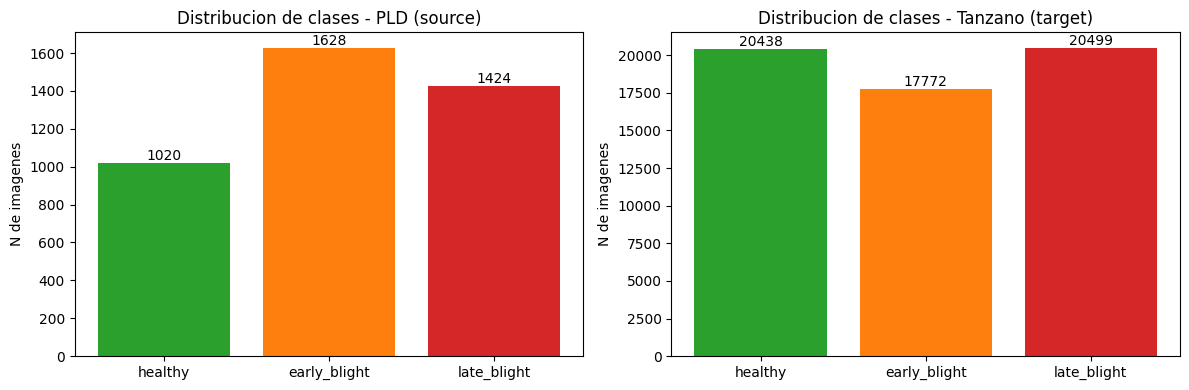

In [ ]:
# Graficos de distribucion por dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, dfx) in zip(axes, [("PLD (source)", df_source), ("Tanzano (target)", df_target)]):
    conteo = dfx["label"].value_counts().reindex(CLASS_NAMES)
    ax.bar(conteo.index, conteo.values, color=["#2ca02c", "#ff7f0e", "#d62728"])
    ax.set_title(f"Distribucion de clases - {name}"); ax.set_ylabel("N de imagenes")
    for i, v in enumerate(conteo.values):
        ax.text(i, v, str(int(v)), ha="center", va="bottom")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "distribucion_clases.png", dpi=120, bbox_inches="tight"); plt.show()

## 6. Preprocesamiento de imágenes (corregido)

> ### Decisión clave: NO normalizar a `[0, 1]`
> `EfficientNetB0` de Keras **incluye su propia capa de normalización interna** y está
> diseñada para recibir imágenes en **rango `[0, 255]`**. En la versión anterior dividíamos
> entre 255, por lo que tras la normalización interna las imágenes quedaban casi en cero y el
> modelo **no aprendía** (colapsaba a una sola clase, *loss* ≈ `ln(3)` ≈ 1.098).
>
> **Pipeline correcto:** leer → decodificar → `float32` → *resize* `224x224x3` →
> **mantener `[0, 255]`** → entregar a EfficientNetB0 (que normaliza internamente).

Pasos del preprocesamiento (informe): reetiquetado (sección 5), redimensionamiento a
`224x224x3` y normalización — esta última **delegada a EfficientNet** para no duplicarla.
También verificamos imágenes corruptas.

In [ ]:
# Verificacion de imagenes corruptas (descarta las que no se puedan abrir)
def filtrar_corruptas(df, nombre=""):
    validas, n_corruptas = [], 0
    for ruta in df["filepath"]:
        try:
            with Image.open(ruta) as im:
                im.verify()
            validas.append(True)
        except Exception:
            validas.append(False); n_corruptas += 1
    print(f"  {nombre}: {n_corruptas} corruptas descartadas de {len(df)}")
    return df[pd.Series(validas, index=df.index)].reset_index(drop=True)

# Se filtra fuente completa. Para Tanzano se filtra luego de muestrear, porque puede ser grande.
df_source = filtrar_corruptas(df_source, "PLD")
df_all = pd.concat([df_source, df_target], ignore_index=True)

  PLD: 0 corruptas descartadas de 4072


In [ ]:
# Carga + preprocesamiento para tf.data: float32 en rango [0, 255] (SIN dividir entre 255)
def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)  # soporta jpg/png/bmp/webp
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # se mantiene en [0, 255]
    return img, label


## 7. Partición de datos

**PLD (fuente)** — partición estratificada: `train_source` 70 % · `val_source` 15 % ·
`test_source` 15 %.

**Tanzano (objetivo)**:

* `target_adaptation` — pool para adaptación K-shot.
* `target_test` — separado, sólo evaluación final.

> **Sin fuga:** primero separamos `target_test`. Tanto el subconjunto K-shot como el conjunto
de validación para MFT salen únicamente de `target_adaptation`. Tanzano reservado para test no
se usa para entrenar.

In [ ]:
# Particion estratificada del dominio FUENTE (70/15/15)
df_train_src, df_temp_src = train_test_split(
    df_source, test_size=0.30, stratify=df_source["label_id"], random_state=SEED)
df_val_src, df_test_src = train_test_split(
    df_temp_src, test_size=0.50, stratify=df_temp_src["label_id"], random_state=SEED)
for nm, d in [("train_source", df_train_src), ("val_source", df_val_src), ("test_source", df_test_src)]:
    print(f"{nm:14s}: {len(d):5d} -> {dict(d['label'].value_counts().reindex(CLASS_NAMES))}")

train_source  :  2850 -> {'healthy': np.int64(714), 'early_blight': np.int64(1139), 'late_blight': np.int64(997)}
val_source    :   611 -> {'healthy': np.int64(153), 'early_blight': np.int64(244), 'late_blight': np.int64(214)}
test_source   :   611 -> {'healthy': np.int64(153), 'early_blight': np.int64(245), 'late_blight': np.int64(213)}


In [ ]:
# Muestreo balanceado del dominio OBJETIVO
def muestrear_por_clase(df, n_por_clase, seed=SEED):
    if n_por_clase is None:
        return df.reset_index(drop=True)
    partes = [df[df["label"] == c].sample(min(n_por_clase, len(df[df["label"] == c])), random_state=seed)
              for c in CLASS_NAMES]
    return pd.concat(partes).sample(frac=1, random_state=seed).reset_index(drop=True)

df_target_s = muestrear_por_clase(df_target, TARGET_SAMPLE_PER_CLASS)
df_target_s = filtrar_corruptas(df_target_s, "Tanzano (muestra)")

# Separacion adaptation / test (estratificada, SIN fuga)
df_target_adaptation, df_target_test = train_test_split(
    df_target_s, test_size=0.50, stratify=df_target_s["label_id"], random_state=SEED)
df_target_adaptation = df_target_adaptation.reset_index(drop=True)
df_target_test = df_target_test.reset_index(drop=True)
print("target_adaptation:", len(df_target_adaptation), dict(df_target_adaptation["label"].value_counts().reindex(CLASS_NAMES)))
print("target_test:      ", len(df_target_test), dict(df_target_test["label"].value_counts().reindex(CLASS_NAMES)))

  Tanzano (muestra): 0 corruptas descartadas de 1800
target_adaptation: 900 {'healthy': np.int64(300), 'early_blight': np.int64(300), 'late_blight': np.int64(300)}
target_test:       900 {'healthy': np.int64(300), 'early_blight': np.int64(300), 'late_blight': np.int64(300)}


In [ ]:
# Subconjuntos balanceados desde target_adaptation: K-shot (entrenamiento) y K-val (validacion MFT)
def subset_balanceado(df, k_per_class, excluir_filepaths=None, seed=SEED):
    excluir = excluir_filepaths or set()
    partes = []
    for c in CLASS_NAMES:
        sub = df[(df["label"] == c) & (~df["filepath"].isin(excluir))]
        if len(sub) < k_per_class:
            print(f"  [aviso] clase {c} solo tiene {len(sub)} imagenes (< {k_per_class})")
        partes.append(sub.sample(min(k_per_class, len(sub)), random_state=seed))
    return pd.concat(partes).sample(frac=1, random_state=seed).reset_index(drop=True)

# K-shot para entrenar MFT
df_kshot = subset_balanceado(df_target_adaptation, K_SHOT)
# Pequena validacion para MFT (disjunta del K-shot y del test -> sin fuga)
df_kval = subset_balanceado(df_target_adaptation, max(10, K_SHOT),
                            excluir_filepaths=set(df_kshot["filepath"]))
print(f"K-shot (K={K_SHOT}):", len(df_kshot), dict(df_kshot["label"].value_counts().reindex(CLASS_NAMES)))
print("K-val (MFT):       ", len(df_kval), dict(df_kval["label"].value_counts().reindex(CLASS_NAMES)))
# Chequeo anti-fuga
assert len(set(df_kshot["filepath"]) & set(df_target_test["filepath"])) == 0
assert len(set(df_kval["filepath"]) & set(df_target_test["filepath"])) == 0
assert len(set(df_kshot["filepath"]) & set(df_kval["filepath"])) == 0
print("OK: sin solapamiento entre kshot, kval y target_test")

K-shot (K=20): 60 {'healthy': np.int64(20), 'early_blight': np.int64(20), 'late_blight': np.int64(20)}
K-val (MFT):        60 {'healthy': np.int64(20), 'early_blight': np.int64(20), 'late_blight': np.int64(20)}
OK: sin solapamiento entre kshot, kval y target_test


## 8. Construcción de `tf.data.Dataset`

Función reutilizable: lee, decodifica, redimensiona, mantiene `[0,255]`, asigna etiqueta,
*batch* y *prefetch*. El *data augmentation* **no** va aquí: se aplica dentro del modelo y
**solo en entrenamiento** (sección 10).

In [ ]:
def make_dataset(df, batch_size=BATCH_SIZE, shuffle=False):
    if len(df) == 0:
        raise ValueError("DataFrame vacio: no se puede construir el dataset.")
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values,
                                             df["label_id"].values.astype("int32")))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

source_train_ds = make_dataset(df_train_src, shuffle=True)
source_val_ds   = make_dataset(df_val_src,   shuffle=False)
source_test_ds  = make_dataset(df_test_src,  shuffle=False)
target_test_ds  = make_dataset(df_target_test, shuffle=False)
target_kshot_ds = make_dataset(df_kshot,     shuffle=True)
target_kval_ds  = make_dataset(df_kval,      shuffle=False)

for xb, yb in source_train_ds.take(1):
    print("batch:", xb.shape, "| etiquetas:", yb.numpy()[:8],
          "| rango pixeles:", float(xb.numpy().min()), "-", float(xb.numpy().max()))
print("Datasets construidos (rango de pixeles ~0-255, correcto para EfficientNet).")

batch: (16, 224, 224, 3) | etiquetas: [0 1 2 1 1 1 0 0] | rango pixeles: 0.0 - 255.0
Datasets construidos (rango de pixeles ~0-255, correcto para EfficientNet).


## 9. Diagnóstico previo al entrenamiento

Antes de entrenar, confirmamos que **los datos y las etiquetas están bien**. Si algo está mal
aquí (labels desalineadas, datasets vacíos, archivos basura), el modelo nunca aprenderá.

In [ ]:
# 9.1 Distribucion de clases en todas las particiones
def dist(df):
    return dict(df["label"].value_counts().reindex(CLASS_NAMES))
print("=== Distribucion de clases por particion ===")
print("train_source     :", dist(df_train_src))
print("val_source       :", dist(df_val_src))
print("test_source      :", dist(df_test_src))
print("target_adaptation:", dist(df_target_adaptation))
print("target_test      :", dist(df_target_test))

# 9.2 Datasets vacios
for nm, d in [("train_source", df_train_src), ("val_source", df_val_src),
              ("test_source", df_test_src), ("target_adaptation", df_target_adaptation),
              ("target_test", df_target_test)]:
    if len(d) == 0:
        raise ValueError(f"Particion vacia detectada: {nm}")
print("OK: ninguna particion esta vacia.")

=== Distribucion de clases por particion ===
train_source     : {'healthy': np.int64(714), 'early_blight': np.int64(1139), 'late_blight': np.int64(997)}
val_source       : {'healthy': np.int64(153), 'early_blight': np.int64(244), 'late_blight': np.int64(214)}
test_source      : {'healthy': np.int64(153), 'early_blight': np.int64(245), 'late_blight': np.int64(213)}
target_adaptation: {'healthy': np.int64(300), 'early_blight': np.int64(300), 'late_blight': np.int64(300)}
target_test      : {'healthy': np.int64(300), 'early_blight': np.int64(300), 'late_blight': np.int64(300)}
OK: ninguna particion esta vacia.


In [ ]:
# 9.3 Verificacion de que label_id corresponde a la etiqueta correcta
print("=== Verificacion label <-> label_id (debe ser healthy=0, early_blight=1, late_blight=2) ===")
chequeo = (df_all.groupby(["label", "label_id"]).size().reset_index(name="n"))
print(chequeo.to_string(index=False))
# Tabla cruzada original_label vs label_id para confirmar la homologacion
print("\n=== original_label -> label_id ===")
print(pd.crosstab(df_all["original_label"], df_all["label_id"]))
for c, i in CLASS_TO_ID.items():
    assert (df_all[df_all["label"] == c]["label_id"] == i).all(), f"label_id incorrecto para {c}"
print("\nOK: cada label_id corresponde a su clase correcta.")

=== Verificacion label <-> label_id (debe ser healthy=0, early_blight=1, late_blight=2) ===
       label  label_id     n
early_blight         1 19400
     healthy         0 21458
 late_blight         2 21923

=== original_label -> label_id ===
label_id            0      1      2
original_label                     
Early_Blight        0   1628      0
Healthy          1020      0      0
Late_Blight         0      0   1424
earlyblt            0  17772      0
healthy         20438      0      0
lateblt             0      0  20499

OK: cada label_id corresponde a su clase correcta.


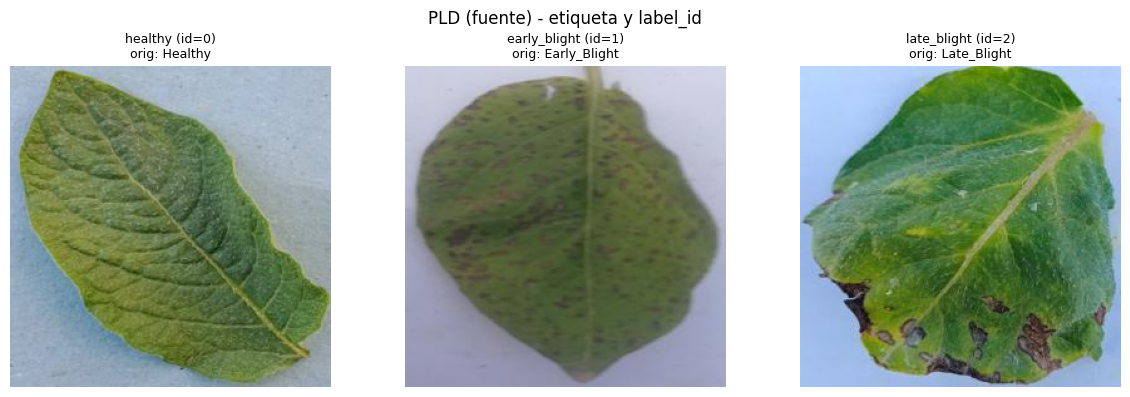

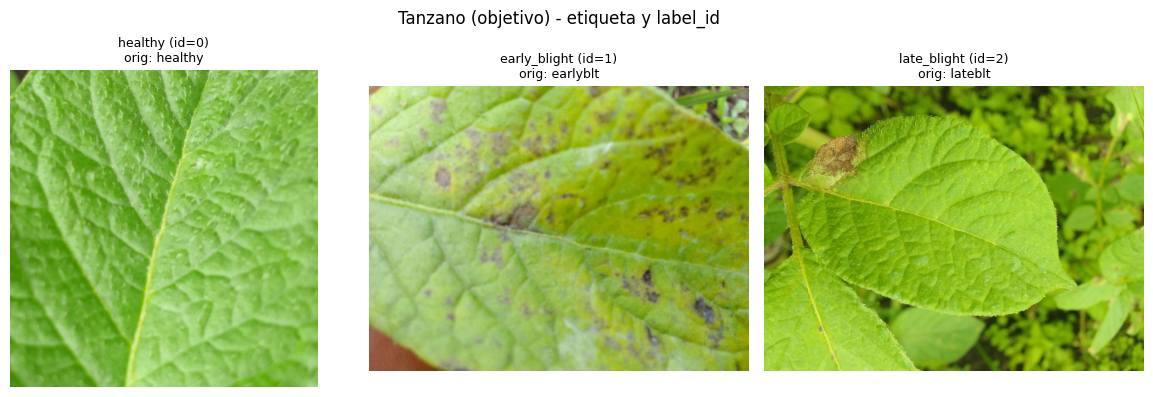

In [ ]:
# 9.4 Mostrar imagenes reales con su label textual y label_id (confirmacion visual)
def mostrar_con_labels(df, titulo, fname, n=3):
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(12, 4))
    for ax, clase in zip(axes, CLASS_NAMES):
        sub = df[df["label"] == clase]
        if len(sub) == 0:
            ax.axis("off"); ax.set_title(f"{clase}\n(sin imagenes)"); continue
        fila = sub.sample(1, random_state=SEED).iloc[0]
        ax.imshow(Image.open(fila["filepath"]).convert("RGB"))
        ax.set_title(f"{fila['label']} (id={fila['label_id']})\norig: {fila['original_label']}", fontsize=9)
        ax.axis("off")
    fig.suptitle(titulo); plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches="tight"); plt.show()

mostrar_con_labels(df_source, "PLD (fuente) - etiqueta y label_id", "ejemplos_pld.png")
mostrar_con_labels(df_target, "Tanzano (objetivo) - etiqueta y label_id", "ejemplos_tanzano.png")

In [ ]:
# 9.5 Confirmar que NO se esten leyendo archivos basura de macOS (._ o __MACOSX)
def contar_basura(carpeta):
    carpeta = Path(carpeta)
    if not carpeta.exists():
        return 0
    return sum(1 for p in carpeta.rglob("*")
               if p.name.startswith("._") or "__MACOSX" in p.parts)

basura_src = contar_basura(SOURCE_DIR); basura_tgt = contar_basura(TARGET_DIR)
print(f"Archivos basura macOS detectados -> PLD: {basura_src}, Tanzano: {basura_tgt}")
incluidos = [f for f in df_all["filepath"] if Path(f).name.startswith("._") or "__MACOSX" in Path(f).parts]
print("Archivos basura que entraron al DataFrame:", len(incluidos), "(debe ser 0)")
assert len(incluidos) == 0
print("OK: no se leyeron archivos __MACOSX ni '._*'.")

Archivos basura macOS detectados -> PLD: 0, Tanzano: 0
Archivos basura que entraron al DataFrame: 0 (debe ser 0)
OK: no se leyeron archivos __MACOSX ni '._*'.


## 10. Manejo del desbalance (class_weight raw vs suavizado)

PLD suele estar menos desbalanceado que PLD, pero el manejo de pesos se conserva para
que el experimento sea controlable.

* Calculamos y mostramos el `class_weight` original.
* Creamos una versión suavizada: raíz cuadrada de los pesos + recorte máximo (`CLASS_WEIGHT_MAX`).
* `USE_CLASS_WEIGHT` permite entrenar con o sin pesos. Por defecto está desactivado para verificar
primero que el pipeline aprende.

> El desbalance se evalúa con métricas macro, matriz de confusión y diagnóstico de predicciones,
no sólo con *accuracy*.

In [ ]:
clases_presentes = np.unique(df_train_src["label_id"].values)
pesos_raw = compute_class_weight("balanced", classes=clases_presentes, y=df_train_src["label_id"].values)
class_weight_raw = {int(c): float(w) for c, w in zip(clases_presentes, pesos_raw)}

# Suavizado: raiz cuadrada + recorte
pesos_suav = np.clip(np.sqrt(pesos_raw), None, CLASS_WEIGHT_MAX)
class_weight_suave = {int(c): float(w) for c, w in zip(clases_presentes, pesos_suav)}

print("class_weight RAW     :", {ID_TO_CLASS[k]: round(v, 3) for k, v in class_weight_raw.items()})
print("class_weight SUAVIZADO:", {ID_TO_CLASS[k]: round(v, 3) for k, v in class_weight_suave.items()})

# Pesos efectivos segun configuracion
class_weight_efectivo = class_weight_suave if USE_CLASS_WEIGHT else None
print("\nUSE_CLASS_WEIGHT =", USE_CLASS_WEIGHT,
      "->", "se usa el suavizado" if USE_CLASS_WEIGHT else "se entrena SIN class_weight (recomendado primero)")

## 11. Modelo EfficientNetB0, augmentation, callbacks y funciones de evaluación

Arquitectura (entrada en `[0,255]`, EfficientNet normaliza internamente):

```
Input 224x224x3 (0-255)
[Data augmentation opcional, solo en training]
EfficientNetB0(include_top=False, weights="imagenet")
GlobalAveragePooling2D -> Dropout -> Dense(128, relu) -> Dense(3, softmax)
```

Optimizer **Adam** · Loss `sparse_categorical_crossentropy` · Métrica `accuracy`.

In [ ]:
# --------- Data augmentation (rango 0-255, solo activo en entrenamiento) ---------
def build_augment_campo():
    capas = [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),                 # opera de forma relativa (sin value_range)
    ]
    if hasattr(layers, "RandomBrightness"):
        capas.append(layers.RandomBrightness(0.15, value_range=(0, 255)))  # consistente con 0-255
    capas.append(layers.GaussianNoise(0.03))         # capa NATIVA (sin custom layers)
    return models.Sequential(capas, name="augment_campo")

augment_base  = None                 # MB: sin aumento intensivo
augment_campo = build_augment_campo()  # MA: aumento moderado orientado a campo
print("Augmentation lista. Capas MA:", [l.name for l in augment_campo.layers])

Augmentation lista. Capas MA: ['random_flip', 'random_rotation', 'random_zoom', 'random_contrast', 'random_brightness', 'gaussian_noise']


In [ ]:
# --------- Constructor del modelo ---------
def build_model(augment=None, dropout=0.3, dense_units=128):
    "EfficientNetB0 (entrada 0-255) + cabezal. Devuelve (model, base_model)."
    inputs = layers.Input(shape=IMG_SHAPE)               # imagenes en 0-255
    x = augment(inputs) if augment is not None else inputs
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    base_model.trainable = False                          # base congelada por defecto
    y = layers.GlobalAveragePooling2D(name="gap")(base_model.output)
    y = layers.Dropout(dropout, name="dropout")(y)
    y = layers.Dense(dense_units, activation="relu", name="dense_128")(y)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="salida")(y)
    return models.Model(inputs, outputs), base_model

def compilar(model, lr):
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

_demo, _ = build_model(augment=None)
_demo.summary()
del _demo

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# --------- Callbacks reutilizables ---------
def make_callbacks(ckpt_name, patience, usar_checkpoint=True, usar_val=True):
    "EarlyStopping + ReduceLROnPlateau (+ ModelCheckpoint del mejor modelo por val_loss)."
    monitor = "val_loss" if usar_val else "loss"
    cbs = [
        EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]
    if usar_checkpoint:
        cbs.append(ModelCheckpoint(filepath=str(MODELS_DIR / ckpt_name),
                                   monitor=monitor, save_best_only=True, verbose=0))
    return cbs

In [ ]:
# --------- Funciones de evaluacion y diagnostico de colapso ---------
def predecir(model, dataset):
    y_true, y_pred = [], []
    for xb, yb in dataset:
        probs = model.predict(xb, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1)); y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, dataset, class_names, nombre=""):
    y_true, y_pred = predecir(model, dataset)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n=== Evaluacion: {nombre} ===")
    print(f"  Accuracy={acc:.4f} | Precision macro={prec:.4f} | Recall macro={rec:.4f} | F1 macro={f1:.4f}")
    print(classification_report(y_true, y_pred, labels=list(range(len(class_names))),
                                target_names=class_names, zero_division=0))
    return {"nombre": nombre, "accuracy": acc, "precision_macro": prec, "recall_macro": rec,
            "f1_macro": f1, "y_true": y_true, "y_pred": y_pred}

def diagnosticar_colapso(res, class_names, umbral=0.90):
    "Compara distribucion real vs predicha y advierte si el modelo colapsa a una clase."
    y_true, y_pred = res["y_true"], res["y_pred"]
    real = pd.Series(y_true).value_counts().reindex(range(len(class_names)), fill_value=0)
    pred = pd.Series(y_pred).value_counts().reindex(range(len(class_names)), fill_value=0)
    print(f"\n--- Diagnostico de colapso: {res['nombre']} ---")
    print("  Clase         | reales | predichas")
    for i, c in enumerate(class_names):
        print(f"  {c:13s} | {int(real[i]):6d} | {int(pred[i]):6d}")
    frac_max = pred.max() / max(pred.sum(), 1)
    clase_dom = class_names[int(pred.idxmax())]
    if frac_max >= umbral:
        print(f"  *** ADVERTENCIA: posible COLAPSO -> {frac_max*100:.1f}% de predicciones en '{clase_dom}'. ***")
        print("      Causas posibles: desbalance/class_weight agresivo, learning rate alto,")
        print("      preprocesamiento incorrecto, augmentation excesiva o labels mal alineadas.")
        return True
    print(f"  OK: predicciones repartidas (maximo {frac_max*100:.1f}% en '{clase_dom}').")
    return False

def plot_confusion_matrix(y_true, y_pred, class_names, titulo, fname):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(5, 4.2)); im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Real"); ax.set_title(titulo)
    thr = cm.max()/2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thr else "black")
    fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches="tight"); plt.show()

def plot_training_history(history, titulo, fname):
    h = history.history if hasattr(history, "history") else history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h.get("loss", []), label="train")
    if "val_loss" in h: axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(f"Loss - {titulo}"); axes[0].set_xlabel("Epoca"); axes[0].legend()
    axes[1].plot(h.get("accuracy", []), label="train")
    if "val_accuracy" in h: axes[1].plot(h["val_accuracy"], label="val")
    axes[1].set_title(f"Accuracy - {titulo}"); axes[1].set_xlabel("Epoca"); axes[1].legend()
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches="tight"); plt.show()

def guardar_historial(history, fname):
    h = history.history if hasattr(history, "history") else history
    pd.DataFrame(h).to_csv(LOGS_DIR / fname, index=False)

def guardar_metricas(res_source, res_target, fname):
    filas = []
    for dominio, r in [("source_test", res_source), ("target_test", res_target)]:
        if r is None: continue
        filas.append({"dominio": dominio, "accuracy": r["accuracy"], "precision_macro": r["precision_macro"],
                      "recall_macro": r["recall_macro"], "f1_macro": r["f1_macro"]})
    pd.DataFrame(filas).to_csv(TABLES_DIR / fname, index=False)

## 12. Sanity check (¿el pipeline puede aprender?)

Experimento **pequeño y separado** del experimento principal: tomamos **20 imágenes por clase**
de PLD y entrenamos EfficientNetB0 **sin augmentation y sin class_weight**. Si el
preprocesamiento, la carga y las labels están bien, el modelo debe ser capaz de
**sobreajustar** este subconjunto (accuracy de entrenamiento alta). Si **no sube**, el problema
está en los datos/labels/preprocesamiento, **no** en las épocas.

Sanity subset: 60 {'healthy': np.int64(20), 'early_blight': np.int64(20), 'late_blight': np.int64(20)}

Accuracy de entrenamiento tras 30 epocas: 1.0000
>> SANITY OK: el modelo SI puede aprender. El pipeline esta correcto.


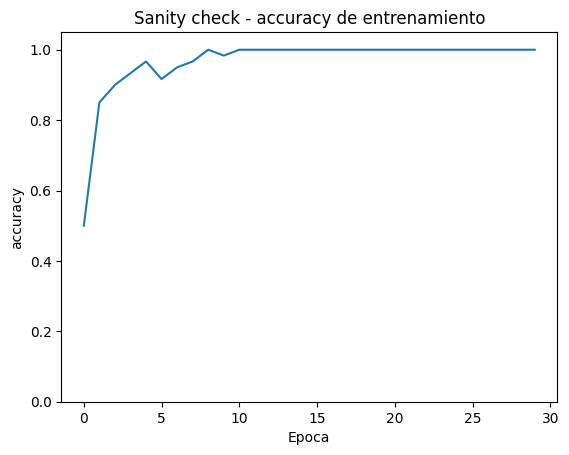

In [ ]:
set_seeds(SEED)
df_sanity = subset_balanceado(df_train_src, 20)
sanity_ds = make_dataset(df_sanity, batch_size=BATCH_SIZE, shuffle=True)
print("Sanity subset:", len(df_sanity), dict(df_sanity["label"].value_counts().reindex(CLASS_NAMES)))

modelo_sanity, _ = build_model(augment=None)
compilar(modelo_sanity, lr=LR_HEAD)
hist_sanity = modelo_sanity.fit(sanity_ds, epochs=EPOCHS_SANITY, verbose=0)

acc_final = hist_sanity.history["accuracy"][-1]
print(f"\nAccuracy de entrenamiento tras {EPOCHS_SANITY} epocas: {acc_final:.4f}")
if acc_final >= 0.80:
    print(">> SANITY OK: el modelo SI puede aprender. El pipeline esta correcto.")
else:
    print(">> SANITY FALLA: el modelo NO logra sobreajustar 60 imagenes.")
    print("   Revisa labels, preprocesamiento (rango 0-255) o la carga de imagenes ANTES de continuar.")

plt.plot(hist_sanity.history["accuracy"]); plt.title("Sanity check - accuracy de entrenamiento")
plt.xlabel("Epoca"); plt.ylabel("accuracy"); plt.ylim(0, 1.05)
plt.savefig(FIGURES_DIR / "sanity_check.png", dpi=120, bbox_inches="tight"); plt.show()
del modelo_sanity

## 13. Estrategia MB — Modelo Base

EfficientNetB0 con **PLD**, **sin aumento intensivo**. Base congelada, se entrena el
cabezal hasta `MAX_EPOCHS_MB` con **EarlyStopping** (`patience=10`, `restore_best_weights`).
Se evalúa en `source_test_ds` y `target_test_ds`.

Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 78s 259ms/step - accuracy: 0.9144 - loss: 0.2354 - val_accuracy: 0.9640 - val_loss: 0.1018 - learning_rate: 0.0010
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9586 - loss: 0.1218 - val_accuracy: 0.9771 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9625 - loss: 0.1058 - val_accuracy: 0.9673 - val_loss: 0.0927 - learning_rate: 0.0010
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9653 - loss: 0.1006 - val_accuracy: 0.9689 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9674 - loss: 0.0933 - val_accuracy: 0.9673 - val_loss: 0.0971 - learning_rate: 0.0010
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.9726 - loss: 0.0780 - val_accuracy: 0.9771 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 7/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9719 -

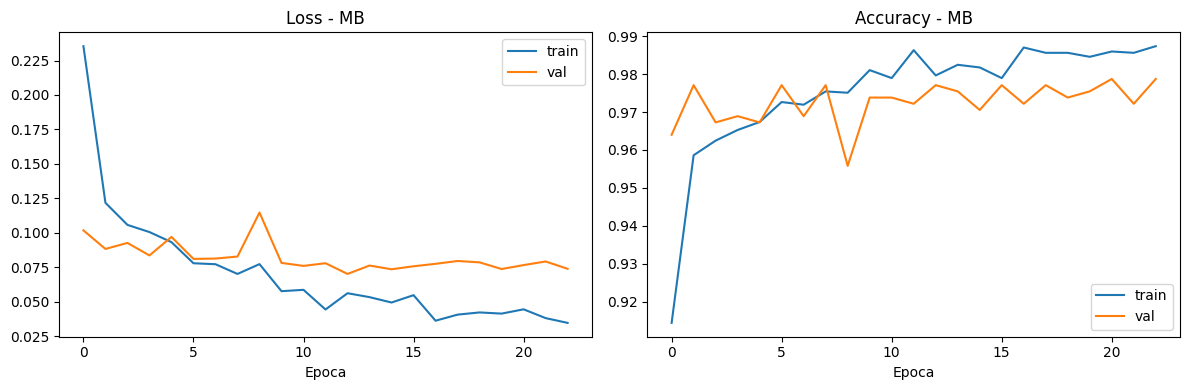

In [ ]:
set_seeds(SEED)
modelo_MB, base_MB = build_model(augment=augment_base)
compilar(modelo_MB, lr=LR_HEAD)

hist_MB = modelo_MB.fit(source_train_ds, validation_data=source_val_ds,
                        epochs=MAX_EPOCHS_MB, class_weight=None,
                        callbacks=make_callbacks("modelo_MB_best.keras", PATIENCE_MB), verbose=1)

plot_training_history(hist_MB, "MB", "curvas_MB.png")
guardar_historial(hist_MB, "historial_MB.csv")


=== Evaluacion: MB - source_test ===
  Accuracy=0.9885 | Precision macro=0.9873 | Recall macro=0.9880 | F1 macro=0.9876
              precision    recall  f1-score   support

     healthy       0.97      0.99      0.98       153
early_blight       0.99      1.00      0.99       245
 late_blight       1.00      0.98      0.99       213

    accuracy                           0.99       611
   macro avg       0.99      0.99      0.99       611
weighted avg       0.99      0.99      0.99       611


=== Evaluacion: MB - target_test ===
  Accuracy=0.6389 | Precision macro=0.7967 | Recall macro=0.6389 | F1 macro=0.6182
              precision    recall  f1-score   support

     healthy       0.99      0.65      0.79       300
early_blight       0.91      0.27      0.41       300
 late_blight       0.49      1.00      0.65       300

    accuracy                           0.64       900
   macro avg       0.80      0.64      0.62       900
weighted avg       0.80      0.64      0.62       9

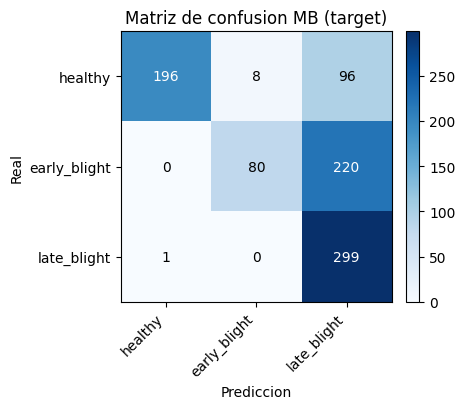


MB guardado en outputs/models/modelo_MB.keras


In [ ]:
# Evaluacion MB (el modelo ya tiene los MEJORES pesos por restore_best_weights)
res_MB_source = evaluate_model(modelo_MB, source_test_ds, CLASS_NAMES, "MB - source_test")
res_MB_target = evaluate_model(modelo_MB, target_test_ds, CLASS_NAMES, "MB - target_test")
diagnosticar_colapso(res_MB_source, CLASS_NAMES)
colapso_MB = diagnosticar_colapso(res_MB_target, CLASS_NAMES)

plot_confusion_matrix(res_MB_target["y_true"], res_MB_target["y_pred"], CLASS_NAMES,
                      "Matriz de confusion MB (target)", "matriz_confusion_MB.png")
modelo_MB.save(MODELS_DIR / "modelo_MB.keras")
guardar_metricas(res_MB_source, res_MB_target, "metricas_MB.csv")
print("\nMB guardado en outputs/models/modelo_MB.keras")

## 14. Estrategia MA — Modelo con Aumento de Datos

PLD + **augmentation orientado a campo** (rango `[0,255]`, solo en training).

* **Fase 1:** base congelada, entrenar cabezal (hasta 100 épocas, `patience=10`).
* **Fase 2:** *fine-tuning parcial* — descongelar ~20 % de las últimas capas, **BatchNorm
  congelado**, `lr=1e-5`, **recompilar** (hasta 50 épocas, `patience=5`).

In [ ]:
set_seeds(SEED)
modelo_MA, base_MA = build_model(augment=augment_campo)
compilar(modelo_MA, lr=LR_HEAD)

print(">>> MA Fase 1: entrenamiento del cabezal")
hist_MA1 = modelo_MA.fit(source_train_ds, validation_data=source_val_ds,
                         epochs=MAX_EPOCHS_MA_HEAD, class_weight=None,
                         callbacks=make_callbacks("modelo_MA_f1_best.keras", PATIENCE_MA_HEAD), verbose=1)

>>> MA Fase 1: entrenamiento del cabezal
Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accuracy: 0.8947 - loss: 0.2655 - val_accuracy: 0.8887 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9432 - loss: 0.1546 - val_accuracy: 0.9542 - val_loss: 0.1258 - learning_rate: 0.0010
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9523 - loss: 0.1339 - val_accuracy: 0.9656 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9470 - loss: 0.1425 - val_accuracy: 0.9493 - val_loss: 0.1566 - learning_rate: 0.0010
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9540 - loss: 0.1245 - val_accuracy: 0.9673 - val_loss: 0.1056 - learning_rate: 0.0010
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9502 - loss: 0.1201
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
179/179 ━━━━━━━━━━━━

In [ ]:
print(">>> MA Fase 2: fine-tuning parcial (ultimo ~20% de capas, BatchNorm congelado)")

def descongelar_ultimo_porcentaje(base_model, pct=0.20):
    base_model.trainable = True
    n = len(base_model.layers); corte = int(n * (1 - pct))
    for i, capa in enumerate(base_model.layers):
        if isinstance(capa, layers.BatchNormalization):
            capa.trainable = False
        else:
            capa.trainable = i >= corte
    print(f"  Capas base entrenables: {sum(c.trainable for c in base_model.layers)}/{n} (desde {corte})")

descongelar_ultimo_porcentaje(base_MA, pct=0.20)
compilar(modelo_MA, lr=LR_FT)   # recompilar tras cambiar trainable

hist_MA2 = modelo_MA.fit(source_train_ds, validation_data=source_val_ds,
                         epochs=MAX_EPOCHS_MA_FT, class_weight=None,
                         callbacks=make_callbacks("modelo_MA_best.keras", PATIENCE_MA_FT), verbose=1)

>>> MA Fase 2: fine-tuning parcial (ultimo ~20% de capas, BatchNorm congelado)
  Capas base entrenables: 38/239 (desde 191)
Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.9775 - loss: 0.0701 - val_accuracy: 0.9689 - val_loss: 0.0885 - learning_rate: 1.0000e-05
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.9765 - loss: 0.0709 - val_accuracy: 0.9705 - val_loss: 0.0783 - learning_rate: 1.0000e-05
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9800 - loss: 0.0614 - val_accuracy: 0.9689 - val_loss: 0.0864 - learning_rate: 1.0000e-05
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.9804 - loss: 0.0594 - val_accuracy: 0.9673 - val_loss: 0.0982 - learning_rate: 1.0000e-05
Epoch 5/50
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9789 - loss: 0.0713
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.9814 - loss: 0.0616 - va

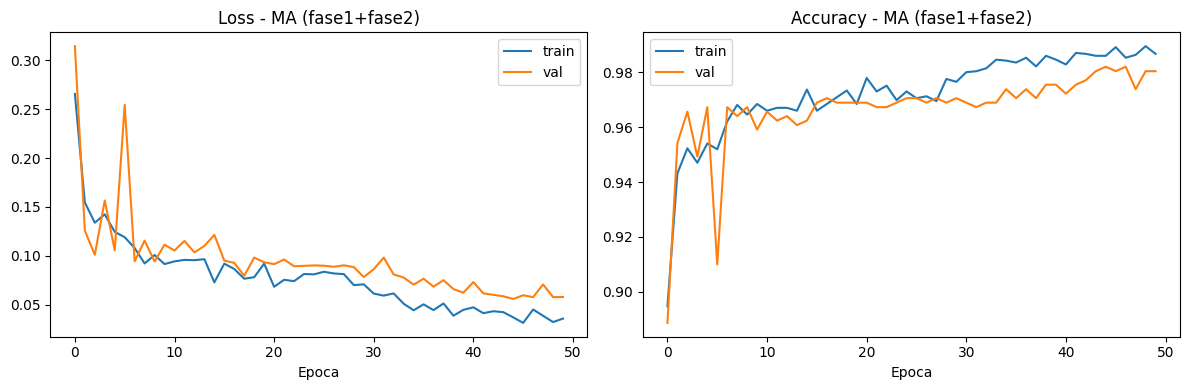

In [ ]:
# Historial combinado fase1+fase2
hist_MA_comb = {k: list(hist_MA1.history.get(k, [])) + list(hist_MA2.history.get(k, []))
                for k in set(hist_MA1.history) | set(hist_MA2.history)}
plot_training_history(hist_MA_comb, "MA (fase1+fase2)", "curvas_MA.png")
guardar_historial(hist_MA_comb, "historial_MA.csv")


=== Evaluacion: MA - source_test ===
  Accuracy=0.9918 | Precision macro=0.9909 | Recall macro=0.9928 | F1 macro=0.9918
              precision    recall  f1-score   support

     healthy       0.98      1.00      0.99       153
early_blight       0.99      0.99      0.99       245
 late_blight       1.00      0.99      1.00       213

    accuracy                           0.99       611
   macro avg       0.99      0.99      0.99       611
weighted avg       0.99      0.99      0.99       611


=== Evaluacion: MA - target_test ===
  Accuracy=0.7711 | Precision macro=0.8522 | Recall macro=0.7711 | F1 macro=0.7510
              precision    recall  f1-score   support

     healthy       0.98      0.95      0.97       300
early_blight       0.97      0.37      0.54       300
 late_blight       0.60      0.99      0.75       300

    accuracy                           0.77       900
   macro avg       0.85      0.77      0.75       900
weighted avg       0.85      0.77      0.75       9

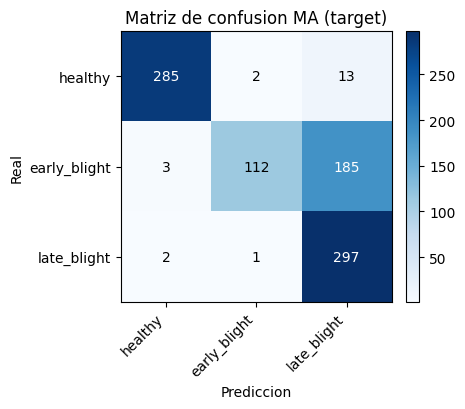


MA guardado en outputs/models/modelo_MA.keras


In [ ]:
res_MA_source = evaluate_model(modelo_MA, source_test_ds, CLASS_NAMES, "MA - source_test")
res_MA_target = evaluate_model(modelo_MA, target_test_ds, CLASS_NAMES, "MA - target_test")
diagnosticar_colapso(res_MA_source, CLASS_NAMES)
colapso_MA = diagnosticar_colapso(res_MA_target, CLASS_NAMES)

plot_confusion_matrix(res_MA_target["y_true"], res_MA_target["y_pred"], CLASS_NAMES,
                      "Matriz de confusion MA (target)", "matriz_confusion_MA.png")
modelo_MA.save(MODELS_DIR / "modelo_MA.keras")
guardar_metricas(res_MA_source, res_MA_target, "metricas_MA.csv")
print("\nMA guardado en outputs/models/modelo_MA.keras")

## 15. Estrategia MFT — Fine-tuning *K-shot*

Partimos del **mejor modelo MA** y lo adaptamos con `target_kshot_ds` (K=20/clase) durante
hasta 50 épocas (`patience=5`, `lr=1e-5`). Validamos con `target_kval_ds` (subconjunto de
`target_adaptation`, **disjunto del test**). Evaluación **solo** en `target_test_ds`.

> **No continuamos si MA colapsó.** Como ya no hay capas personalizadas, recargar
> `modelo_MA.keras` es seguro; aun así, si falla la carga usamos el modelo MA **en memoria**.

Modelo MA cargado desde disco para MFT.
>>> MFT: adaptacion K-shot con K=20 imagenes/clase de Tanzano
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8333 - loss: 1.0910 - val_accuracy: 0.7833 - val_loss: 1.0634 - learning_rate: 1.0000e-05
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.8833 - loss: 0.7496 - val_accuracy: 0.8167 - val_loss: 0.8676 - learning_rate: 1.0000e-05
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 0.9000 - loss: 0.5927 - val_accuracy: 0.8333 - val_loss: 0.7113 - learning_rate: 1.0000e-05
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 0.9000 - loss: 0.4589 - val_accuracy: 0.8667 - val_loss: 0.5904 - learning_rate: 1.0000e-05
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 450ms/step - accuracy: 0.8833 - loss: 0.3335 - val_accuracy: 0.9333 - val_loss: 0.4962 - learning_rate: 1.0000e-05
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.8333 - loss: 0.5741 - val_accuracy: 0.9333 - val_loss: 0.4214 - le

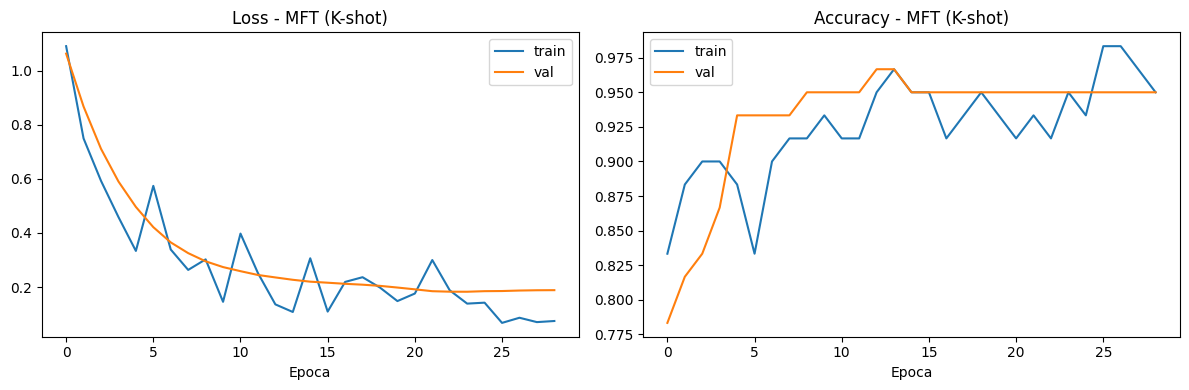

In [ ]:
set_seeds(SEED)

if colapso_MA:
    print("*** MA COLAPSO en el dominio objetivo. NO se ejecuta MFT automaticamente. ***")
    print("    Revisa el diagnostico de MA (preprocesamiento, class_weight, lr o augmentation)")
    print("    antes de adaptar. Para forzar MFT, ejecuta manualmente la celda de adaptacion.")
    res_MFT_target = None
else:
    # Partimos del MEJOR MA. Sin custom layers, load_model es seguro; fallback al MA en memoria.
    try:
        modelo_MFT = tf.keras.models.load_model(MODELS_DIR / "modelo_MA.keras")
        print("Modelo MA cargado desde disco para MFT.")
    except Exception as e:
        print("No se pudo cargar desde disco (", e, "). Se clona el MA en memoria.")
        modelo_MFT = tf.keras.models.clone_model(modelo_MA)
        modelo_MFT.set_weights(modelo_MA.get_weights())

    compilar(modelo_MFT, lr=LR_MFT)
    print(f">>> MFT: adaptacion K-shot con K={K_SHOT} imagenes/clase de Tanzano")
    hist_MFT = modelo_MFT.fit(target_kshot_ds, validation_data=target_kval_ds,
                              epochs=MAX_EPOCHS_MFT,
                              callbacks=make_callbacks("modelo_MFT_best.keras", PATIENCE_MFT), verbose=1)
    plot_training_history(hist_MFT, "MFT (K-shot)", "curvas_MFT.png")
    guardar_historial(hist_MFT, "historial_MFT.csv")

Mejor modelo MFT cargado desde checkpoint.

=== Evaluacion: MFT - target_test ===
  Accuracy=0.9300 | Precision macro=0.9330 | Recall macro=0.9300 | F1 macro=0.9297
              precision    recall  f1-score   support

     healthy       0.99      1.00      0.99       300
early_blight       0.95      0.84      0.89       300
 late_blight       0.86      0.95      0.90       300

    accuracy                           0.93       900
   macro avg       0.93      0.93      0.93       900
weighted avg       0.93      0.93      0.93       900


--- Diagnostico de colapso: MFT - target_test ---
  Clase         | reales | predichas
  healthy       |    300 |    303
  early_blight  |    300 |    266
  late_blight   |    300 |    331
  OK: predicciones repartidas (maximo 36.8% en 'late_blight').


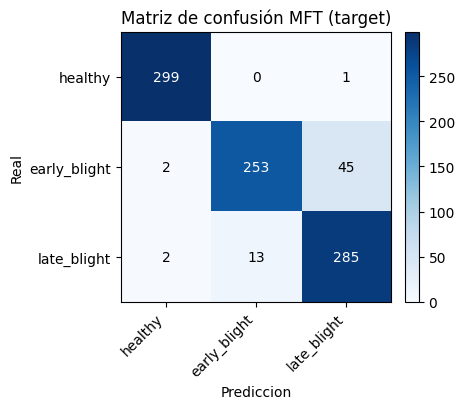


MFT guardado en outputs/models/modelo_MFT.keras


In [ ]:
if colapso_MA:
    print("MFT omitido porque MA colapsó. No hay métricas MFT en esta corrida.")
    res_MFT_target = None
else:
    # Cargar el mejor MFT guardado por ModelCheckpoint, si existe
    best_mft_path = MODELS_DIR / "modelo_MFT_best.keras"

    if best_mft_path.exists():
        modelo_MFT = tf.keras.models.load_model(best_mft_path)
        print("Mejor modelo MFT cargado desde checkpoint.")
    else:
        print("No se encontró checkpoint MFT. Se evalúa el modelo MFT actual en memoria.")

    res_MFT_target = evaluate_model(modelo_MFT, target_test_ds, CLASS_NAMES, "MFT - target_test")
    diagnosticar_colapso(res_MFT_target, CLASS_NAMES)

    plot_confusion_matrix(
        res_MFT_target["y_true"],
        res_MFT_target["y_pred"],
        CLASS_NAMES,
        "Matriz de confusión MFT (target)",
        "matriz_confusion_MFT.png"
    )

    modelo_MFT.save(MODELS_DIR / "modelo_MFT.keras")
    guardar_metricas(None, res_MFT_target, "metricas_MFT.csv")
    print("\nMFT guardado en outputs/models/modelo_MFT.keras")

## 16. Evaluación comparativa final

Comparamos MB, MA y MFT en el **dominio objetivo** (`target_test_ds`).

In [ ]:
filas = [
    {"Modelo": "MB", "Accuracy target": res_MB_target["accuracy"], "Precision macro": res_MB_target["precision_macro"],
     "Recall macro": res_MB_target["recall_macro"], "F1 macro": res_MB_target["f1_macro"]},
    {"Modelo": "MA", "Accuracy target": res_MA_target["accuracy"], "Precision macro": res_MA_target["precision_macro"],
     "Recall macro": res_MA_target["recall_macro"], "F1 macro": res_MA_target["f1_macro"]},
]
if res_MFT_target is not None:
    filas.append({"Modelo": "MFT", "Accuracy target": res_MFT_target["accuracy"],
                  "Precision macro": res_MFT_target["precision_macro"],
                  "Recall macro": res_MFT_target["recall_macro"], "F1 macro": res_MFT_target["f1_macro"]})
comparativa = pd.DataFrame(filas).round(4)
comparativa.to_csv(TABLES_DIR / "comparativa_final.csv", index=False)
print("Tabla comparativa (dominio objetivo Tanzano):")
comparativa

Tabla comparativa (dominio objetivo Tanzano):


,Modelo,Accuracy target,Precision macro,Recall macro,F1 macro
0,MB,0.6389,0.7967,0.6389,0.6182
1,MA,0.7711,0.8522,0.7711,0.7510
2,MFT,0.9300,0.9330,0.9300,0.9297


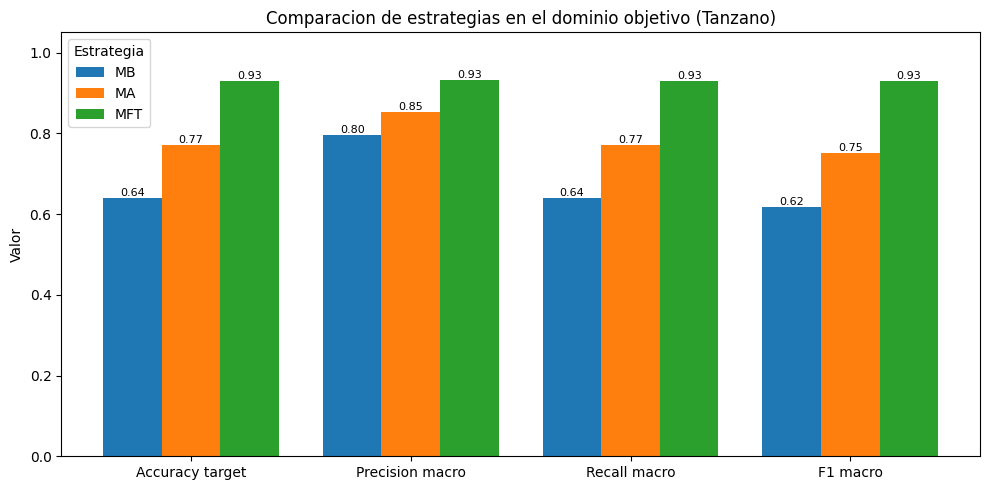

In [ ]:
metricas = ["Accuracy target", "Precision macro", "Recall macro", "F1 macro"]
modelos = list(comparativa["Modelo"])
x = np.arange(len(metricas)); ancho = 0.8 / len(modelos)
fig, ax = plt.subplots(figsize=(10, 5))
for i, modelo in enumerate(modelos):
    vals = comparativa[comparativa["Modelo"] == modelo][metricas].values.flatten()
    barras = ax.bar(x + (i - (len(modelos)-1)/2) * ancho, vals, ancho, label=modelo)
    for b, v in zip(barras, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metricas); ax.set_ylim(0, 1.05); ax.set_ylabel("Valor")
ax.set_title("Comparacion de estrategias en el dominio objetivo (Tanzano)"); ax.legend(title="Estrategia")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "comparativa_final.png", dpi=120, bbox_inches="tight"); plt.show()

## 17. Conclusiones automáticas del experimento

Interpreta los **resultados reales** de la corrida (no inventados): brecha de dominio, efecto
de cada estrategia y mejor generalización a campo.

In [ ]:
acc_mb, acc_ma = res_MB_target["accuracy"], res_MA_target["accuracy"]
acc_mb_src = res_MB_source["accuracy"]
acc_mft = res_MFT_target["accuracy"] if res_MFT_target is not None else None
brecha_mb = acc_mb_src - acc_mb

L = ["CONCLUSIONES AUTOMATICAS DEL EXPERIMENTO", "=" * 50]
L.append(f"- MB accuracy en dominio fuente (PLD):       {acc_mb_src:.4f}")
L.append(f"- MB accuracy en dominio objetivo (Tanzano): {acc_mb:.4f}")
L.append(f"- Brecha de dominio del modelo base (fuente - objetivo): {brecha_mb:.4f} ({brecha_mb*100:.1f} pp)")
L.append("")
L.append("Desempeno en el dominio objetivo (lo que importa para generalizar a campo):")
L.append(f"   MB : accuracy={acc_mb:.4f}, F1 macro={res_MB_target['f1_macro']:.4f}")
L.append(f"   MA : accuracy={acc_ma:.4f}, F1 macro={res_MA_target['f1_macro']:.4f}")
if acc_mft is not None:
    L.append(f"   MFT: accuracy={acc_mft:.4f}, F1 macro={res_MFT_target['f1_macro']:.4f}")
else:
    L.append("   MFT: no ejecutado (MA colapso en esta corrida).")
L.append("")
L.append(f"- MA vs MB en target: {acc_ma - acc_mb:+.4f}")
if acc_mft is not None:
    L.append(f"- MFT vs MB en target: {acc_mft - acc_mb:+.4f}")
    L.append(f"- MFT vs MA en target: {acc_mft - acc_ma:+.4f}")
cand = [("MB", acc_mb), ("MA", acc_ma)] + ([("MFT", acc_mft)] if acc_mft is not None else [])
mejor = max(cand, key=lambda t: t[1])
L.append("")
L.append(f">> Estrategia con mejor generalizacion al campo: {mejor[0]} (accuracy target = {mejor[1]:.4f}).")
L.append("")
L.append("Nota: una caida fuerte de MB entre fuente y objetivo confirma la brecha de dominio")
L.append("descrita en el informe. El desbalance se interpreta con metricas macro y matriz de")
L.append("confusion, no solo con accuracy.")

texto = "\n".join(L)
print(texto)
with open(LOGS_DIR / "conclusiones.txt", "w", encoding="utf-8") as f:
    f.write(texto)
print("\nConclusiones guardadas en outputs/logs/conclusiones.txt")

---

### Archivos generados

```
outputs/
├── models/    modelo_MB.keras, modelo_MA.keras, modelo_MFT.keras  (+ *_best.keras)
├── figures/   distribucion_clases.png, ejemplos_*.png, sanity_check.png,
│              curvas_*.png, matriz_confusion_*.png, comparativa_final.png
├── tables/    resumen_datasets.csv, metricas_*.csv, comparativa_final.csv
└── logs/      historial_*.csv, conclusiones.txt
```

**Buenas prácticas:** rutas relativas, datasets intactos, sin fuga entre adaptación y test,
preprocesamiento `0-255` correcto para EfficientNet, augmentation solo en training,
`class_weight` suavizado y desactivable, sanity check, detección de colapso, callbacks y carga
del mejor modelo antes de evaluar. Cambia `K_SHOT` o `USE_CLASS_WEIGHT` en la sección 3 para
experimentar.

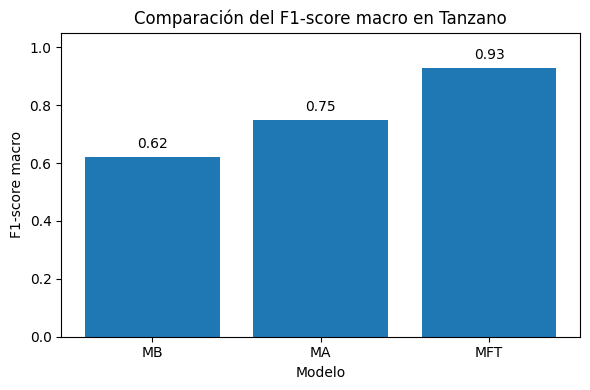

Figura guardada en: /content/f1_macro_comparacion.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Valores de F1 macro observados en tu gráfica
df_f1 = pd.DataFrame({
    "Modelo": ["MB", "MA", "MFT"],
    "F1 macro": [0.62, 0.75, 0.93]
})

plt.figure(figsize=(6, 4))
bars = plt.bar(df_f1["Modelo"], df_f1["F1 macro"])

plt.ylim(0, 1.05)
plt.xlabel("Modelo")
plt.ylabel("F1-score macro")
plt.title("Comparación del F1-score macro en Tanzano")

# Mostrar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Guardar figura
output_path = Path("/content/f1_macro_comparacion.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_path}")